# CIS164 Final Project: Crime Rates V. Weath Inequality

# Research Question

**Research Question**
- Is there a relationship between crime rates and wealth inequality in the US?

**Why this matters**
- Understanding the root causes of crime can aid the creation of positive domestic policy.
- The US prison system does not aim to rehabilitate but to keep people incarcerated.


# Dataset Description

**Dataset Source**
- Unified Crime Reporting Statistics, The US Department of Justice (DOJ) and the Federal Bureau of Investigation (FBI)
- GeoWealthLab.org 
- Suss, J., Kemeny, T., & Connor, D. S. (2024). GEOWEALTH-US: Spatial wealth inequality data for the United States, 
1960–2020. Scientific Data, 11(1), 253.

**Population Representation**
- Both data sets contain statistics that strictly apply to citizes in the United States

**Key Variables**
- `States`
- `Violent and Property Crime Rates`
- `Weath_Gini`

**Limitations**
- Distribution of Violent Crime Rate is heavily skewed right.


# Import Libraries

- **Pandas** was used to manipulate the data
- **Matplotlib**, **Seaborn** and **Plotly** was required to display the data
- **Scipy** was used to perform significace tests on the data



In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats

# Load Data

My data is comprised of 2 csvs; **state_crime.csv** and **state_wealth_inequality** which have a common column by state.
- **state_crime.csv** contains comprehensive and thorough varieties of different recorded crime rates in each state and their populations.
- **state_weath_inequality.csv** has everything helpfull in viewing wealth distribution in all states.


In [9]:
state_crime = pd.read_csv("state_crime.csv")
wealth_in = pd.read_csv("state_wealth_inequality.csv")
state_crime.head()

,State,Year,Data.Population,Data.Rates.Property.All,Data.Rates.Property.Burglary,Data.Rates.Property.Larceny,Data.Rates.Property.Motor,Data.Rates.Violent.All,Data.Rates.Violent.Assault,Data.Rates.Violent.Murder,...,Data.Rates.Violent.Robbery,Data.Totals.Property.All,Data.Totals.Property.Burglary,Data.Totals.Property.Larceny,Data.Totals.Property.Motor,Data.Totals.Violent.All,Data.Totals.Violent.Assault,Data.Totals.Violent.Murder,Data.Totals.Violent.Rape,Data.Totals.Violent.Robbery
0,Alabama,1960,3266740,1035.4,355.9,592.1,87.3,186.6,138.1,12.4,...,27.5,33823,11626,19344,2853,6097,4512,406,281,898
1,Alabama,1961,3302000,985.5,339.3,569.4,76.8,168.5,128.9,12.9,...,19.1,32541,11205,18801,2535,5564,4255,427,252,630
2,Alabama,1962,3358000,1067.0,349.1,634.5,83.4,157.3,119.0,9.4,...,22.5,35829,11722,21306,2801,5283,3995,316,218,754
3,Alabama,1963,3347000,1150.9,376.9,683.4,90.6,182.7,142.1,10.2,...,24.7,38521,12614,22874,3033,6115,4755,340,192,828
4,Alabama,1964,3407000,1358.7,466.6,784.1,108.0,213.1,163.0,9.3,...,29.1,46290,15898,26713,3679,7260,5555,316,397,992


In [10]:
wealth_in.head()

,year,state,obs,households,wealth_mean,wealth_median,wealth_top1,wealth_top.1,wealth_top.01,wealth_top.001,...,mean_sd,top1_sd,top.1_sd,top.01_sd,top.001_sd,top10_sd,bottom50_sd,top5_sd,top.5_sd,gini_sd
0,1960,alabama,42847,856940.0,77278.162,35100.750,0.211,0.085,0.034,0.014,...,448.374,0.005,0.004,0.002,0.001,0.003,0.000,0.003,0.005,0.017
1,1960,alaska,2750,55000.0,97790.092,36482.414,0.170,0.062,0.026,0.012,...,4025.317,0.032,0.019,0.008,0.003,0.019,0.378,0.025,0.030,0.028
2,1960,arizona,17694,353880.0,108872.732,45300.973,0.218,0.087,0.036,0.014,...,1082.775,0.007,0.004,0.001,0.001,0.004,0.001,0.006,0.006,0.021
3,1960,arkansas,25150,503000.0,73961.529,35263.136,0.161,0.059,0.023,0.009,...,1649.743,0.018,0.012,0.007,0.002,0.011,0.002,0.014,0.018,0.019
4,1960,california,237916,4758320.0,141314.694,60621.910,0.224,0.088,0.036,0.014,...,1547.357,0.009,0.006,0.003,0.001,0.005,0.001,0.006,0.009,0.020


# Data Cleaning

- Both State columns need to be converted to a title-case string
- These data sets must be merged to compare crime rates and wealth inequality.

In [11]:
#state_crime.info()
wealth_in.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 39 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              350 non-null    int64  
 1   state             350 non-null    object 
 2   obs               350 non-null    int64  
 3   households        350 non-null    float64
 4   wealth_mean       350 non-null    float64
 5   wealth_median     350 non-null    float64
 6   wealth_top1       350 non-null    float64
 7   wealth_top.1      350 non-null    float64
 8   wealth_top.01     350 non-null    float64
 9   wealth_top.001    350 non-null    float64
 10  wealth_top10      350 non-null    float64
 11  wealth_bottom50   350 non-null    float64
 12  wealth_gini       350 non-null    float64
 13  wealth_sd         350 non-null    float64
 14  p90               350 non-null    float64
 15  p10               350 non-null    float64
 16  income_mean       350 non-null    float64
 1

In [12]:
state_crime['State'] = state_crime['State'].astype('string').str.title()
wealth_in['state'] = wealth_in['state'].astype('string').str.title()
merged_data = pd.merge(state_crime, wealth_in, left_on='State', right_on='state', how='inner')

In [13]:
state_to_region = {
    'Washington': 'West', 'Oregon': 'West', 'California': 'West', 'Nevada': 'West',
    'Idaho': 'West', 'Montana': 'West', 'Wyoming': 'West', 'Utah': 'West',
    'Colorado': 'West', 'Arizona': 'West', 'New Mexico': 'West', 'Alaska': 'West',
    'Hawaii': 'West', 'North Dakota': 'Midwest', 'South Dakota': 'Midwest',
    'Nebraska': 'Midwest', 'Kansas': 'Midwest', 'Minnesota': 'Midwest', 
    'Iowa': 'Midwest', 'Missouri': 'Midwest', 'Wisconsin': 'Midwest', 
    'Illinois': 'Midwest', 'Michigan': 'Midwest', 'Indiana': 'Midwest', 
    'Ohio': 'Midwest', 'Texas': 'South', 'Oklahoma': 'South', 'Arkansas': 'South',
    'Louisiana': 'South', 'Mississippi': 'South', 'Alabama': 'South', 
    'Tennessee': 'South', 'Kentucky': 'South', 'Georgia': 'South', 
    'Florida': 'South', 'South Carolina': 'South', 'North Carolina': 'South',
    'Virginia': 'South', 'West Virginia': 'South', 'Maryland': 'South', 
    'Delaware': 'South', 'District of Columbia': 'South', 'Pennsylvania': 'Northeast',
    'New Jersey': 'Northeast', 'New York': 'Northeast', 'Connecticut': 'Northeast',
    'Rhode Island': 'Northeast', 'Massachusetts': 'Northeast', 'Vermont': 'Northeast',
    'New Hampshire': 'Northeast', 'Maine': 'Northeast' 
}

merged_data['Region'] = merged_data['state'].map(state_to_region)

In [14]:

display(merged_data.head(20))


,State,Year,Data.Population,Data.Rates.Property.All,Data.Rates.Property.Burglary,Data.Rates.Property.Larceny,Data.Rates.Property.Motor,Data.Rates.Violent.All,Data.Rates.Violent.Assault,Data.Rates.Violent.Murder,...,top1_sd,top.1_sd,top.01_sd,top.001_sd,top10_sd,bottom50_sd,top5_sd,top.5_sd,gini_sd,Region
0,Alabama,1960,3266740,1035.4,355.9,592.1,87.3,186.6,138.1,12.4,...,0.005,0.004,0.002,0.001,0.003,0.000,0.003,0.005,0.017,South
1,Alabama,1960,3266740,1035.4,355.9,592.1,87.3,186.6,138.1,12.4,...,0.002,0.001,0.000,0.000,0.002,0.000,0.002,0.002,0.005,South
2,Alabama,1960,3266740,1035.4,355.9,592.1,87.3,186.6,138.1,12.4,...,0.007,0.005,0.002,0.001,0.004,0.001,0.005,0.008,0.017,South
3,Alabama,1960,3266740,1035.4,355.9,592.1,87.3,186.6,138.1,12.4,...,0.008,0.004,0.001,0.001,0.011,0.001,0.012,0.006,0.010,South
4,Alabama,1960,3266740,1035.4,355.9,592.1,87.3,186.6,138.1,12.4,...,0.016,0.009,0.004,0.002,0.009,0.001,0.013,0.014,0.014,South
5,Alabama,1960,3266740,1035.4,355.9,592.1,87.3,186.6,138.1,12.4,...,0.003,0.001,0.001,0.000,0.003,0.000,0.004,0.002,0.002,South
6,Alabama,1960,3266740,1035.4,355.9,592.1,87.3,186.6,138.1,12.4,...,0.023,0.012,0.006,0.003,0.015,0.002,0.020,0.020,0.012,South
7,Alabama,1961,3302000,985.5,339.3,569.4,76.8,168.5,128.9,12.9,...,0.005,0.004,0.002,0.001,0.003,0.000,0.003,0.005,0.017,South
8,Alabama,1961,3302000,985.5,339.3,569.4,76.8,168.5,128.9,12.9,...,0.002,0.001,0.000,0.000,0.002,0.000,0.002,0.002,0.005,South
9,Alabama,1961,3302000,985.5,339.3,569.4,76.8,168.5,128.9,12.9,...,0.007,0.005,0.002,0.001,0.004,0.001,0.005,0.008,0.017,South


# Exploratory Data Analysis (EDA)

- What are the average Violent and Property Crime Rates? 
    - 400.6 and 3552.54 respectivly
    - **Crime Rate = (Number of Crimes / Population) * 100,000**
- Which state has the highest wealth inequality? 
    - **Nevada** has the highest wealth inequality coefficient
    - **The Gini Coefficient is calculated by taking the area between the line of equality and the lorenz curve (A) and the area below (B)**
    - **Gini Coefficient = A / (A+B)**, which tells us the overall wealth gap between each percentile in society


In [20]:
merged_data['wealth_gini'].describe()

count    20965.000000
mean         0.764431
std          0.045699
min          0.615000
25%          0.735000
50%          0.771000
75%          0.800000
max          0.863000
Name: wealth_gini, dtype: float64

# Visualizations

Each visualization should follow this pattern:

1. Markdown explaining **what the plot shows**
2. Code generating the plot
3. Markdown interpreting the results

Example explanation:
- This boxplot compares sleep hours across age groups


# Variable distributions

Viewing the distributions of...
- Violent Crime Rates
- Property Crime Rates
- Wealth Gini Coefficient

Text(0.5, 1.0, 'Distribution of Violent Crime Rate')

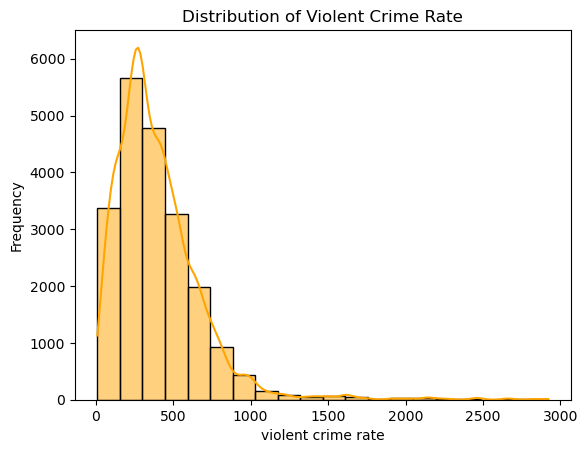

In [ ]:
sns.histplot(data=merged_data, x='Data.Rates.Violent.All', bins=20, kde=True, color='orange')
plt.xlabel('violent crime rate')
plt.ylabel('Frequency')
plt.title('Distribution of Violent Crime Rate')

The distribution of **violent crime rate** is heavily **skewed-right**.
- n = **20965**
- Mean = **400.17**
- Standard Deviation = **290.19**
- Max = **2921.80**
- Min = **9.50**

Text(0.5, 1.0, 'Distribution of Property Crime Rate')

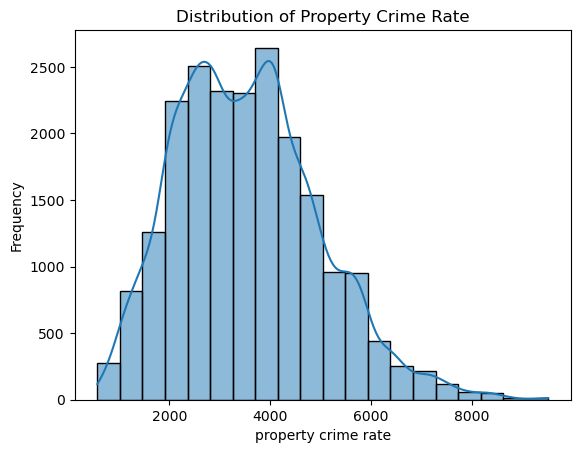

In [ ]:
sns.histplot(data=merged_data, x='Data.Rates.Property.All', bins=20, kde=True)
plt.xlabel('property crime rate')
plt.ylabel('Frequency')
plt.title('Distribution of Property Crime Rate')

The distribution of **property crime rate** is **approximatly normal**.
- n = **20965**
- Mean = **3552.54**
- Standard Deviation = **1426.81**
- Max = **9512.10**
- Min = **573.10**

Text(0.5, 1.0, 'Distribution of Wealth Gini Coefficient')

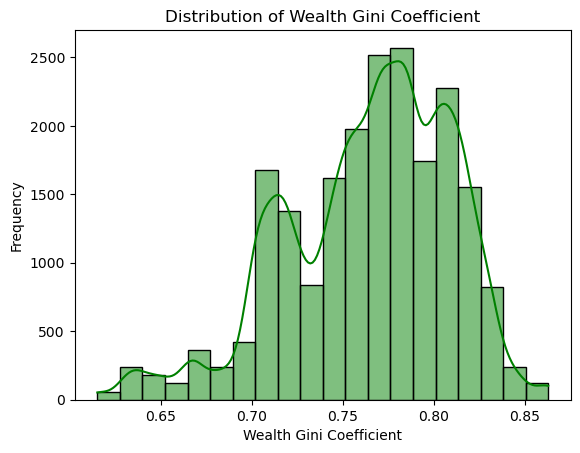

In [ ]:
sns.histplot(data=merged_data, x='wealth_gini', bins=20, kde=True, color='green')
plt.xlabel('Wealth Gini Coefficient')
plt.ylabel('Frequency')
plt.title('Distribution of Wealth Gini Coefficient')

The distribution of **wealth gini** is **approximatly normal**.
- n = **20965**
- Mean = **0.76**
- Standard Deviation = **0.05**
- Max = **0.86**
- Min = **0.62**

# Relationships Between Crime Rate and Wealth Inequality

Viewing the relationships between...
- Wealth Gini and *Violent* Crime Rate
- Wealth Gini and *Property* Crime Rate

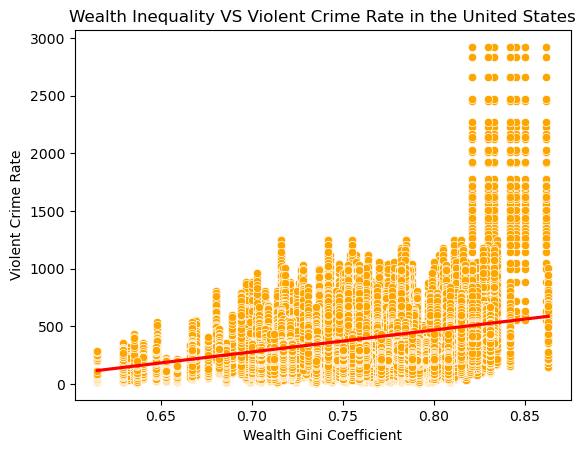

In [ ]:
sns.scatterplot(data=merged_data, x='wealth_gini', y='Data.Rates.Violent.All', color='orange')
sns.regplot(data=merged_data, x='wealth_gini', y='Data.Rates.Violent.All', scatter=False, ci=True, line_kws={"color": "red"})
plt.xlabel('Wealth Gini Coefficient')
plt.ylabel('Violent Crime Rate')
plt.title('Wealth Inequality VS Violent Crime Rate in the United States')
plt.show()

In [ ]:
r, p = stats.spearmanr(merged_data['wealth_gini'], merged_data['Data.Rates.Violent.All'])
print(f"correlation = {r:.2f}, p-value = {p}")

correlation = 0.24, p-value = 7.820176316367561e-278


- There is a **weak positive (0.24) correlation** between *wealth gini* and *violent crime rates*
- **0.0576 (0.24^2) percent** of the varience in *violent crime rate* can be explained in the *wealth gini coefficient*
- There is a **statistically significant relationship** between *wealth gini* and *violent crime rates* due to the **P-value = 7.82e-278 < 0.05**

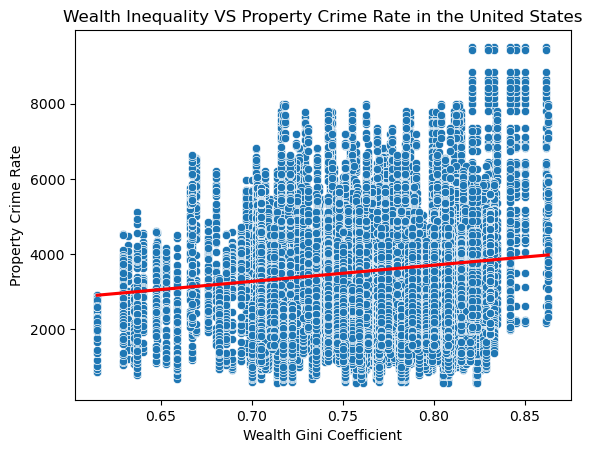

In [ ]:
sns.scatterplot(data=merged_data, x='wealth_gini', y='Data.Rates.Property.All')
sns.regplot(data=merged_data, x='wealth_gini', y='Data.Rates.Property.All', scatter=False, ci=True, line_kws={"color": "red"})
plt.xlabel('Wealth Gini Coefficient')
plt.ylabel('Property Crime Rate')
plt.title('Wealth Inequality VS Property Crime Rate in the United States')
plt.show()

In [ ]:
r, p = stats.pearsonr(merged_data["wealth_gini"], merged_data["Data.Rates.Property.All"])
print(f"correlation = {r:.2f}, p-value = {p}")

correlation = 0.14, p-value = 3.3726925969693882e-90


- There is a **weak positive (0.14) correlation** between *wealth gini* and *property crime rates*
- **0.0196 (0.14^2) percent** of the varience in *property crime rate* can be explained in the *wealth gini coefficient*
- There is a **statistically significant relationship** between *wealth gini* and *property crime rates* due to the **P-value = 3.37e-90 < 0.05**

# Distributions of variables by region of the United States

Viewing different US regions' distributions in...
- Violent Crime Rate
- Property Crime Rate
- Wealth Gini Coefficient

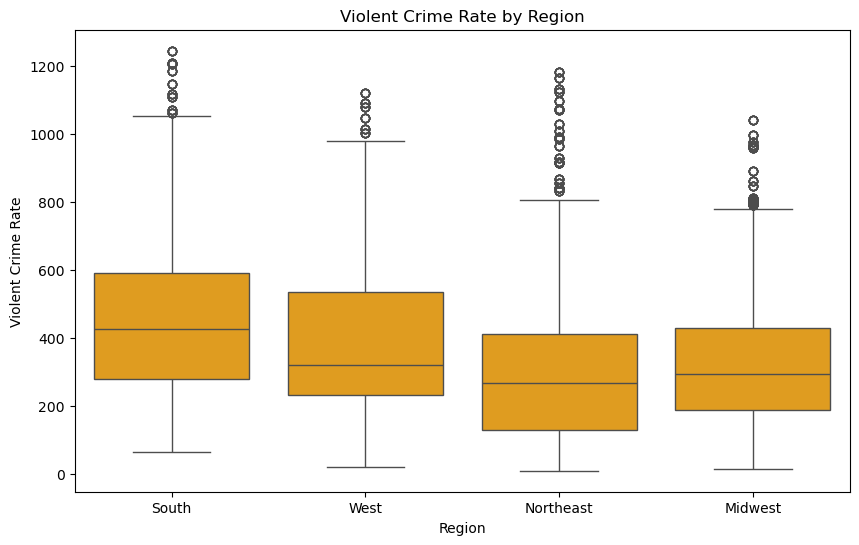

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=merged_data, x='Region', y='Data.Rates.Violent.All', color='orange')
plt.title('Violent Crime Rate by Region')
plt.xlabel('Region')
plt.ylabel('Violent Crime Rate')
plt.show()

In [ ]:
stat, p_value = stats.kruskal(merged_data[merged_data['Region'] == 'Northeast']['Data.Rates.Violent.All'],
                              merged_data[merged_data['Region'] == 'Midwest']['Data.Rates.Violent.All'],
                              merged_data[merged_data['Region'] == 'South']['Data.Rates.Violent.All'],
                              merged_data[merged_data['Region'] == 'West']['Data.Rates.Violent.All'])
print(f"Kruskal-Wallis H-statistic = {stat:.2f}, p-value = {p_value:.4f}")

Kruskal-Wallis H-statistic = 1493.62, p-value = 0.0000


- An **H-test** was required for this portion due to the heavy right skew on the violent crime distribution
- Because the p-value is approximatly 0, there is a **statistically significant difference** in median violent crime rates across regions.
- The South US seems to have the highest mean violent crime rate, but due to the heavy skew, all regions have many outliers.

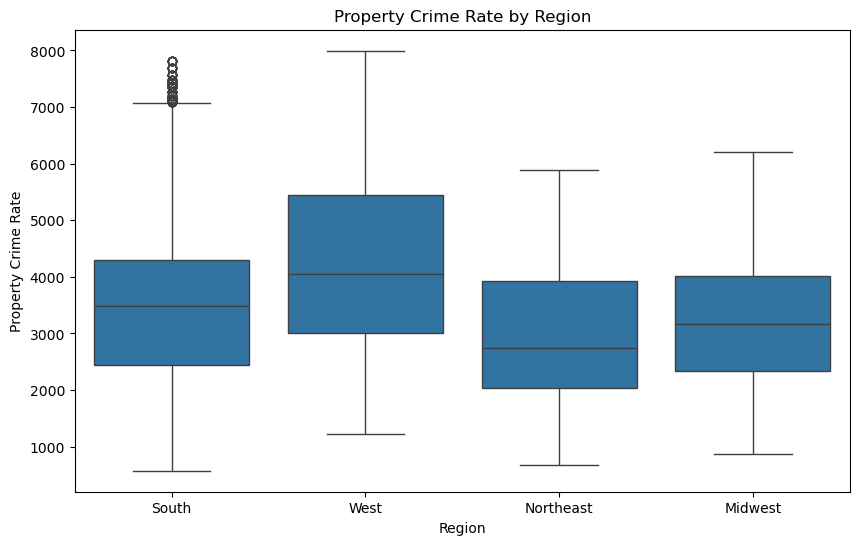

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=merged_data, x='Region', y='Data.Rates.Property.All')
plt.title('Property Crime Rate by Region')
plt.xlabel('Region')
plt.ylabel('Property Crime Rate')
plt.show()

In [21]:
regions = [group['Data.Rates.Property.All'] for name, group in merged_data.groupby('Region')]

f_stat, p_value = stats.f_oneway(*regions)
print(f"ANOVA F-statistic = {f_stat:.2f}, p-value = {p_value:.4f}")

ANOVA F-statistic = 861.35, p-value = 0.0000


- Because the p-value is approximatly 0, there is a **statisically significant difference** in mean property crime rates between regions.
- The West US here has the highest mean property crime rate, while the South US continutes to have many outiers.

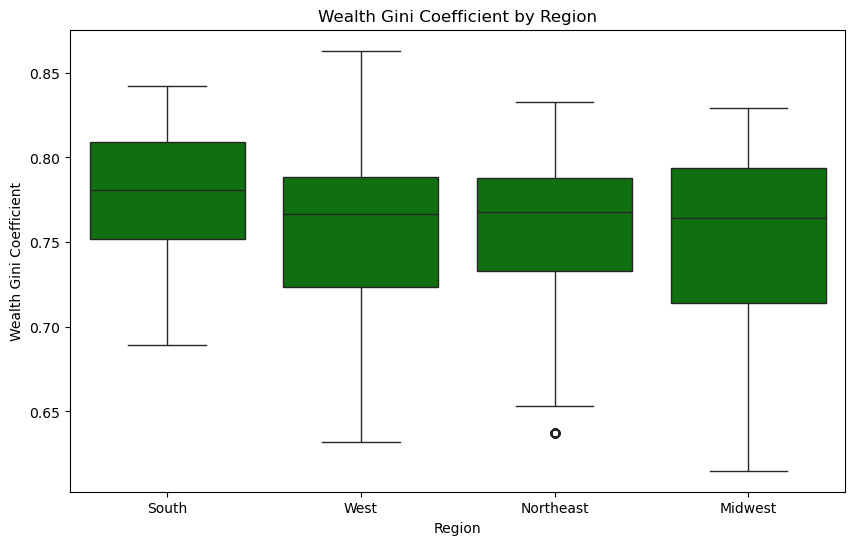

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=merged_data, x='Region', y='wealth_gini', color='Green')
plt.title('Wealth Gini Coefficient by Region')
plt.xlabel('Region')
plt.ylabel('Wealth Gini Coefficient')
plt.show()

In [22]:
regions = [group['wealth_gini'] for name, group in merged_data.groupby('Region')]

f_stat, p_value = stats.f_oneway(*regions)
print(f"ANOVA F-statistic = {f_stat:.2f}, p-value = {p_value:.4f}")

ANOVA F-statistic = 363.05, p-value = 0.0000


- Because the p-value is approximatly 0, there is a **statisically significant difference** in mean wealth gini between regions.
- The South US has the highest mean and the lowest range in Wealth Gini, but all coefficient distributions are way too high especially for 80's and 90's numbers

In [34]:
name_abbr = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA', 
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA', 
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS', 
    'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD', 'Massachusetts': 'MA', 
    'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS', 'Missouri': 'MO', 'Montana': 'MT', 
    'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH', 'New Jersey': 'NJ', 'New Mexico': 'NM', 
    'New York': 'NY', 'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK', 
    'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC', 
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT', 
    'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY', 'District of Columbia': 'DC'
}

merged_data['State_Abbr'] = merged_data['State'].map(name_abbr)

fig = px.choropleth(merged_data, 
                    locations='State_Abbr', 
                    locationmode='USA-states', 
                    color='Data.Rates.Violent.All', 
                    color_continuous_scale='Reds', 
                    scope='usa', 
                    title='Violent Crime Rate by State')
fig.show()

- New Mexico and Alaska have the highest mean violent crime rates
- There doesn't seem to be any obvious geographical trends with violent crime rate, and is likely to do with more complex factors for each individual state.

In [33]:
fig = px.choropleth(merged_data, 
                    locations='State_Abbr', 
                    locationmode='USA-states', 
                    color='Data.Rates.Property.All', 
                    color_continuous_scale='Blues', 
                    scope='usa', 
                    title='Property Crime Rate by State')
fig.show()

- California and Nevada have the highest mean property crime rates
- The graph reinforces the trend that the north east has the lowest mean property crime rates

In [35]:
fig = px.choropleth(merged_data, 
                    locations='State_Abbr', 
                    locationmode='USA-states', 
                    color='wealth_gini', 
                    color_continuous_scale='Greens', 
                    scope='usa', 
                    title='Wealth Gini Coefficient by State')
fig.show()

- Georgia and Lousiana have the highest mean wealth gini coefficient
- While the entire country is pretty dark, there is a clear line along the Bible Belt where wealth distribution splits farther in the south.

# Key Findings and Conclusion

- There is statistically significant evidence that larger gaps in wealth is weakly correlated with (but not causing) higher violent and property related crime rates across the US.
- The South US has higher wealth inequality and violent crime rates on average than the rest of the US
- Due to the very weak correlations, there are likely more forces at play that effect these rates


# Limitations


- Correlation does not imply causation
- Crime rates have more nuance than just "violent" and "property-related" which include large quantities of other crimes under the classification.



# Citations

- Unified Crime Reporting Statistics, The US Department of Justice (DOJ) and the Federal Bureau of Investigation (FBI)
- GeoWealthLab.org 
- Suss, J., Kemeny, T., & Connor, D. S. (2024). GEOWEALTH-US: Spatial wealth inequality data for the United States, 
1960–2020. Scientific Data, 11(1), 253.
